<a href="https://colab.research.google.com/github/JuanMelendres/worldcup-forecast/blob/master/notebooks/fifa_worldcup_score_prediction_tweedie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FIFA World Cup Score Prediction — V4 Tweedie Experiment

## Hybrid model: Elo + XGBoost Poisson + XGBoost Tweedie + Bayesian-style shrinkage

This notebook is designed as a portfolio-ready GitHub/LinkedIn project.

The main improvement in V4 is an experimental **Tweedie regression** section. Poisson is conservative because it assumes the mean and variance of goals are similar. Tweedie regression is more flexible and can model overdispersion:

```text
Poisson: variance ≈ mean
Tweedie: variance = φ × mean^p
```

The goal is not to add random noise artificially, but to add **real volatility features** that represent uncertainty in team performance.

> Educational project only. Not betting advice.

In [ ]:
# ============================================================
# 1. Install dependencies and import libraries
# ============================================================
!pip -q install xgboost

import warnings
warnings.filterwarnings("ignore")

import difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import poisson
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# ============================================================
# 2. Global configuration
# ============================================================
DATASET_URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

MATCH_DATE = "2026-06-23"
TOURNAMENT_NAME = "FIFA World Cup"
NEUTRAL_SITE = True

RECENT_YEARS_FOR_BASELINE = 6
RECENT_MATCHES_FORM = 8
MAX_GOALS = 7
FIRST_HALF_GOAL_SHARE = 0.45

# Ensemble weights
WEIGHT_BASELINE_POISSON = 0.20
WEIGHT_XGBOOST_POISSON = 0.40
WEIGHT_XGBOOST_TWEEDIE = 0.25
WEIGHT_BAYESIAN_STYLE = 0.15

# Tweedie variance power. Try values between 1.1 and 1.6.
TWEEDIE_VARIANCE_POWER = 1.35

MATCHES_TO_PREDICT = [
    ("Portugal", "Uzbekistan"),
    ("England", "Ghana"),
    ("Panama", "Croatia"),
    ("Colombia", "DR Congo"),
]
MATCHES_TO_PREDICT

[('Portugal', 'Uzbekistan'),
 ('England', 'Ghana'),
 ('Panama', 'Croatia'),
 ('Colombia', 'DR Congo')]

## 3. Load historical international results

The dataset contains historical international matches, teams, scores, tournaments and neutral-site flags.

In [ ]:
df = pd.read_csv(DATASET_URL)
df["date"] = pd.to_datetime(df["date"])
df = df.dropna(subset=["home_score", "away_score"]).copy()
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)
df["year"] = df["date"].dt.year

print(f"Matches loaded: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
display(df.tail())

Matches loaded: 49,459
Date range: 1872-11-30 to 2026-06-24


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
49454,2026-06-24,South Africa,South Korea,1,0,FIFA World Cup,Guadalupe,Mexico,True,2026
49455,2026-06-24,Canada,Switzerland,1,2,FIFA World Cup,Vancouver,Canada,False,2026
49456,2026-06-24,Bosnia and Herzegovina,Qatar,3,1,FIFA World Cup,Seattle,United States,True,2026
49457,2026-06-24,Scotland,Brazil,0,3,FIFA World Cup,Miami Gardens,United States,True,2026
49458,2026-06-24,Morocco,Haiti,4,2,FIFA World Cup,Atlanta,United States,True,2026


## 4. Helper functions

These functions resolve team names, create team-level rows, compute recent form, volatility and Elo ratings.

In [ ]:
def available_teams():
    return sorted(set(df["home_team"]).union(set(df["away_team"])))

def resolve_team_name(team_name, verbose=True):
    teams = available_teams()
    if team_name in teams:
        return team_name
    aliases = {
        "USA": "United States",
        "US": "United States",
        "United States of America": "United States",
        "Turkey": "Türkiye",
        "Turkiye": "Türkiye",
        "Cote d'Ivoire": "Ivory Coast",
        "Côte d’Ivoire": "Ivory Coast",
        "Congo DR": "DR Congo",
        "Democratic Republic of Congo": "DR Congo",
        "Cabo Verde": "Cape Verde",
    }
    if team_name in aliases and aliases[team_name] in teams:
        return aliases[team_name]
    close = difflib.get_close_matches(team_name, teams, n=8, cutoff=0.45)
    if verbose:
        print(f"Exact team not found: {team_name}")
        print("Closest matches:", close)
    if close:
        return close[0]
    raise ValueError(f"Could not resolve team name: {team_name}")

def make_team_match_dataset(raw_df):
    home = raw_df[["date", "home_team", "away_team", "home_score", "away_score", "tournament", "neutral"]].copy()
    home.columns = ["date", "team", "opponent", "goals_for", "goals_against", "tournament", "neutral"]
    home["is_home"] = 1
    away = raw_df[["date", "away_team", "home_team", "away_score", "home_score", "tournament", "neutral"]].copy()
    away.columns = ["date", "team", "opponent", "goals_for", "goals_against", "tournament", "neutral"]
    away["is_home"] = 0
    out = pd.concat([home, away], ignore_index=True).sort_values(["date", "team"]).reset_index(drop=True)
    out["year"] = out["date"].dt.year
    return out

def add_recent_form_features(team_df, n_matches=8):
    out = team_df.sort_values(["team", "date"]).copy()
    for col in ["goals_for", "goals_against"]:
        out[f"recent_{col}_avg"] = out.groupby("team")[col].transform(lambda s: s.shift(1).rolling(n_matches, min_periods=1).mean())
    out["points"] = np.select([out["goals_for"] > out["goals_against"], out["goals_for"] == out["goals_against"]], [3, 1], default=0)
    out["recent_points_avg"] = out.groupby("team")["points"].transform(lambda s: s.shift(1).rolling(n_matches, min_periods=1).mean())
    out["recent_goals_for_avg"] = out["recent_goals_for_avg"].fillna(out["goals_for"].mean())
    out["recent_goals_against_avg"] = out["recent_goals_against_avg"].fillna(out["goals_against"].mean())
    out["recent_points_avg"] = out["recent_points_avg"].fillna(out["points"].mean())
    return out

def add_volatility_features(team_df, n_matches=8):
    out = team_df.sort_values(["team", "date"]).copy()
    out["goal_diff"] = out["goals_for"] - out["goals_against"]
    out["abs_goal_diff"] = out["goal_diff"].abs()
    out["recent_goals_for_std"] = out.groupby("team")["goals_for"].transform(lambda s: s.shift(1).rolling(n_matches, min_periods=2).std())
    out["recent_goals_against_std"] = out.groupby("team")["goals_against"].transform(lambda s: s.shift(1).rolling(n_matches, min_periods=2).std())
    out["recent_abs_goal_diff_avg"] = out.groupby("team")["abs_goal_diff"].transform(lambda s: s.shift(1).rolling(n_matches, min_periods=1).mean())
    out["recent_goals_for_std"] = out["recent_goals_for_std"].fillna(out["goals_for"].std())
    out["recent_goals_against_std"] = out["recent_goals_against_std"].fillna(out["goals_against"].std())
    out["recent_abs_goal_diff_avg"] = out["recent_abs_goal_diff_avg"].fillna(out["abs_goal_diff"].mean())
    return out

def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def add_elo_features(raw_df, k=28, home_advantage=60, initial_rating=1500):
    ratings, rows = {}, []
    for _, row in raw_df.sort_values("date").iterrows():
        h, a = row["home_team"], row["away_team"]
        rh, ra = ratings.get(h, initial_rating), ratings.get(a, initial_rating)
        expected_h = expected_score(rh + (0 if row["neutral"] else home_advantage), ra)
        if row["home_score"] > row["away_score"]:
            actual_h, actual_a = 1.0, 0.0
        elif row["home_score"] == row["away_score"]:
            actual_h, actual_a = 0.5, 0.5
        else:
            actual_h, actual_a = 0.0, 1.0
        margin_multiplier = np.log(abs(row["home_score"] - row["away_score"]) + 1) + 1
        rows.append({"date": row["date"], "home_team": h, "away_team": a, "home_elo_pre": rh, "away_elo_pre": ra})
        ratings[h] = rh + k * margin_multiplier * (actual_h - expected_h)
        ratings[a] = ra + k * margin_multiplier * (actual_a - (1 - expected_h))
    return pd.DataFrame(rows), ratings

## 5. Feature engineering

We build a clean modeling table with:

- Elo difference
- Recent attack and defense form
- Recent points
- Real volatility features
- Team/opponent/tournament categorical features

In [ ]:
elo_matches, current_elo_ratings = add_elo_features(df)
df_elo = df.merge(elo_matches, on=["date", "home_team", "away_team"], how="left")
team_df = make_team_match_dataset(df_elo)

home_elo = df_elo[["date", "home_team", "away_team", "home_elo_pre", "away_elo_pre"]].copy()
home_elo.columns = ["date", "team", "opponent", "team_elo_pre", "opponent_elo_pre"]
away_elo = df_elo[["date", "away_team", "home_team", "away_elo_pre", "home_elo_pre"]].copy()
away_elo.columns = ["date", "team", "opponent", "team_elo_pre", "opponent_elo_pre"]
team_df = team_df.merge(pd.concat([home_elo, away_elo]), on=["date", "team", "opponent"], how="left")
team_df = add_recent_form_features(team_df, RECENT_MATCHES_FORM)
team_df = add_volatility_features(team_df, RECENT_MATCHES_FORM)
team_df["elo_diff"] = team_df["team_elo_pre"] - team_df["opponent_elo_pre"]
display(team_df.tail())

,date,team,opponent,goals_for,goals_against,tournament,neutral,is_home,year,team_elo_pre,opponent_elo_pre,recent_goals_for_avg,recent_goals_against_avg,points,recent_points_avg,goal_diff,abs_goal_diff,recent_goals_for_std,recent_goals_against_std,recent_abs_goal_diff_avg,elo_diff
81719,2017-06-29,Åland Islands,Ynys Môn,2,0,Island Games,True,0,2017,1515.948547,1517.269994,0.875,1.625,3,1.125,2,2,0.834523,1.685018,1.250,-1.321447
92593,2023-07-09,Åland Islands,Isle of Wight,0,2,Island Games,True,1,2023,1545.440866,1635.992799,1.000,1.000,0,1.500,-2,2,0.925820,1.069045,1.000,-90.551933
92611,2023-07-10,Åland Islands,Guernsey,1,4,Island Games,False,0,2023,1523.548936,1742.101457,0.750,1.125,0,1.125,-3,3,0.886405,1.125992,1.125,-218.552521
92633,2023-07-11,Åland Islands,Western Isles,0,2,Island Games,True,1,2023,1512.357470,1349.518418,0.875,1.375,0,1.125,-2,2,0.834523,1.505941,1.250,162.839052
92655,2023-07-13,Åland Islands,Falkland Islands,1,1,Island Games,True,1,2023,1470.133504,1151.241320,0.750,1.250,1,1.125,0,0,0.886405,1.388730,1.250,318.892183


## 6. Baseline and Bayesian-style expected goals

The baseline is simple Poisson expected goals.

The Bayesian-style model uses empirical shrinkage, pulling teams with less information toward the global average.

In [ ]:
def baseline_expected_goals(home_team, away_team, neutral=True, recent_years=6):
    home_team, away_team = resolve_team_name(home_team, False), resolve_team_name(away_team, False)
    recent = df[df["date"] >= df["date"].max() - pd.DateOffset(years=recent_years)].copy()
    recent_team_df = make_team_match_dataset(recent)
    global_avg = recent_team_df["goals_for"].mean()
    stats = recent_team_df.groupby("team").agg(matches=("team", "count"), gf=("goals_for", "mean"), ga=("goals_against", "mean")).reset_index()
    stats["attack"] = stats["gf"] / global_avg
    stats["defense_weakness"] = stats["ga"] / global_avg
    def vals(t):
        r = stats[stats["team"] == t]
        return {"attack": 1.0, "defense_weakness": 1.0} if r.empty else r.iloc[0].to_dict()
    hv, av = vals(home_team), vals(away_team)
    home_adv = 1.10 if not neutral else 1.00
    return global_avg * hv["attack"] * av["defense_weakness"] * home_adv, global_avg * av["attack"] * hv["defense_weakness"]

def bayesian_style_expected_goals(home_team, away_team, neutral=True, recent_years=8, prior_strength=12):
    home_team, away_team = resolve_team_name(home_team, False), resolve_team_name(away_team, False)
    recent = df[df["date"] >= df["date"].max() - pd.DateOffset(years=recent_years)].copy()
    team_recent = make_team_match_dataset(recent)
    global_avg = team_recent["goals_for"].mean()
    stats = team_recent.groupby("team").agg(matches=("team", "count"), gf=("goals_for", "mean"), ga=("goals_against", "mean")).reset_index()
    def shrink(value, n):
        w = n / (n + prior_strength)
        return w * value + (1 - w) * global_avg
    stats["attack"] = stats.apply(lambda r: shrink(r["gf"], r["matches"]) / global_avg, axis=1)
    stats["defense_weakness"] = stats.apply(lambda r: shrink(r["ga"], r["matches"]) / global_avg, axis=1)
    def vals(t):
        r = stats[stats["team"] == t]
        return {"attack": 1.0, "defense_weakness": 1.0} if r.empty else r.iloc[0].to_dict()
    hv, av = vals(home_team), vals(away_team)
    home_adv = 1.08 if not neutral else 1.00
    return global_avg * hv["attack"] * av["defense_weakness"] * home_adv, global_avg * av["attack"] * hv["defense_weakness"]

## 7. Train XGBoost Poisson and Tweedie models

The Tweedie model is the new experimental section.

It uses real volatility features instead of artificial random noise.

,model,MAE,RMSE
0,XGBoost Poisson,0.949343,1.268167
1,XGBoost Tweedie,0.941201,1.261130


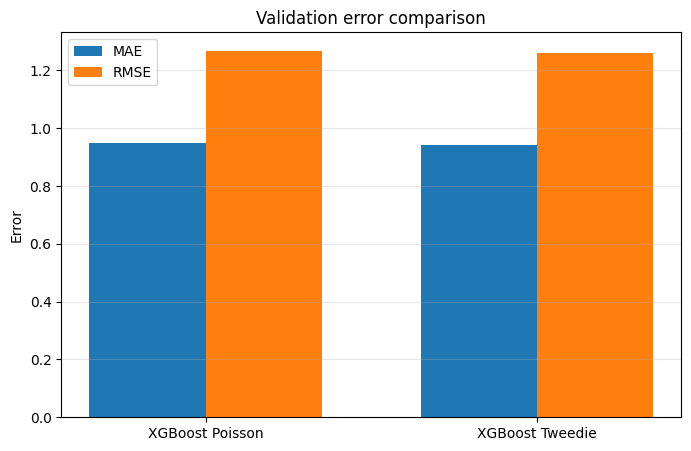

In [ ]:
FEATURES_NUMERIC = [
    "is_home", "neutral", "year", "team_elo_pre", "opponent_elo_pre", "elo_diff",
    "recent_goals_for_avg", "recent_goals_against_avg", "recent_points_avg",
    "recent_goals_for_std", "recent_goals_against_std", "recent_abs_goal_diff_avg",
]
FEATURES_CATEGORICAL = ["team", "opponent", "tournament"]
TARGET = "goals_for"

model_df = team_df.dropna(subset=FEATURES_NUMERIC + FEATURES_CATEGORICAL + [TARGET]).sort_values("date").reset_index(drop=True)
split_idx = int(len(model_df) * 0.8)
train_df, valid_df = model_df.iloc[:split_idx].copy(), model_df.iloc[split_idx:].copy()
X_train, y_train = train_df[FEATURES_NUMERIC + FEATURES_CATEGORICAL], train_df[TARGET]
X_valid, y_valid = valid_df[FEATURES_NUMERIC + FEATURES_CATEGORICAL], valid_df[TARGET]

preprocessor = ColumnTransformer([
    ("numeric", "passthrough", FEATURES_NUMERIC),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), FEATURES_CATEGORICAL),
])

xgb_poisson_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(objective="count:poisson", n_estimators=600, learning_rate=0.025, max_depth=4, subsample=0.9, colsample_bytree=0.9, reg_lambda=2.0, random_state=RANDOM_STATE))
])
xgb_tweedie_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(objective="reg:tweedie", tweedie_variance_power=TWEEDIE_VARIANCE_POWER, n_estimators=600, learning_rate=0.025, max_depth=4, subsample=0.9, colsample_bytree=0.9, reg_lambda=2.0, random_state=RANDOM_STATE))
])

xgb_poisson_model.fit(X_train, y_train)
xgb_tweedie_model.fit(X_train, y_train)

pred_poisson = np.clip(xgb_poisson_model.predict(X_valid), 0.05, 6.0)
pred_tweedie = np.clip(xgb_tweedie_model.predict(X_valid), 0.05, 6.0)

metrics_df = pd.DataFrame([
    {"model": "XGBoost Poisson", "MAE": mean_absolute_error(y_valid, pred_poisson), "RMSE": mean_squared_error(y_valid, pred_poisson) ** 0.5},
    {"model": "XGBoost Tweedie", "MAE": mean_absolute_error(y_valid, pred_tweedie), "RMSE": mean_squared_error(y_valid, pred_tweedie) ** 0.5},
])
display(metrics_df)

plt.figure(figsize=(8, 5))
x = np.arange(len(metrics_df))
width = 0.35
plt.bar(x - width/2, metrics_df["MAE"], width, label="MAE")
plt.bar(x + width/2, metrics_df["RMSE"], width, label="RMSE")
plt.xticks(x, metrics_df["model"])
plt.ylabel("Error")
plt.title("Validation error comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## 8. Future match prediction utilities

In [ ]:
def latest_team_snapshot(team):
    team = resolve_team_name(team, False)
    rows = team_df[team_df["team"] == team].sort_values("date")
    if rows.empty:
        raise ValueError(f"No historical data found for {team}")
    last = rows.iloc[-1]
    return {
        "team_elo_pre": current_elo_ratings.get(team, 1500),
        "recent_goals_for_avg": last["recent_goals_for_avg"],
        "recent_goals_against_avg": last["recent_goals_against_avg"],
        "recent_points_avg": last["recent_points_avg"],
        "recent_goals_for_std": last["recent_goals_for_std"],
        "recent_goals_against_std": last["recent_goals_against_std"],
        "recent_abs_goal_diff_avg": last["recent_abs_goal_diff_avg"],
    }

def build_future_row(team, opponent, is_home, neutral=True, tournament="FIFA World Cup", match_date="2026-06-23"):
    team, opponent = resolve_team_name(team, False), resolve_team_name(opponent, False)
    ts, os = latest_team_snapshot(team), latest_team_snapshot(opponent)
    return pd.DataFrame([{
        "team": team,
        "opponent": opponent,
        "is_home": int(is_home),
        "neutral": bool(neutral),
        "year": pd.to_datetime(match_date).year,
        "team_elo_pre": ts["team_elo_pre"],
        "opponent_elo_pre": os["team_elo_pre"],
        "elo_diff": ts["team_elo_pre"] - os["team_elo_pre"],
        "recent_goals_for_avg": ts["recent_goals_for_avg"],
        "recent_goals_against_avg": ts["recent_goals_against_avg"],
        "recent_points_avg": ts["recent_points_avg"],
        "recent_goals_for_std": ts["recent_goals_for_std"],
        "recent_goals_against_std": ts["recent_goals_against_std"],
        "recent_abs_goal_diff_avg": ts["recent_abs_goal_diff_avg"],
        "tournament": tournament,
    }])

def ml_expected_goals(model, home_team, away_team, neutral=True, tournament="FIFA World Cup", match_date="2026-06-23"):
    home_row = build_future_row(home_team, away_team, 1, neutral, tournament, match_date)
    away_row = build_future_row(away_team, home_team, 0, neutral, tournament, match_date)
    h = float(model.predict(home_row[FEATURES_NUMERIC + FEATURES_CATEGORICAL])[0])
    a = float(model.predict(away_row[FEATURES_NUMERIC + FEATURES_CATEGORICAL])[0])
    return float(np.clip(h, 0.05, 6.0)), float(np.clip(a, 0.05, 6.0))

def score_probability_matrix(home_lambda, away_lambda, max_goals=7):
    matrix = np.zeros((max_goals + 1, max_goals + 1))
    for h in range(max_goals + 1):
        for a in range(max_goals + 1):
            matrix[h, a] = poisson.pmf(h, home_lambda) * poisson.pmf(a, away_lambda)
    return matrix

def apply_dixon_coles_style_adjustment(score_matrix, home_lambda, away_lambda, rho=-0.08):
    adjusted = score_matrix.copy()
    corrections = {(0, 0): 1 - home_lambda * away_lambda * rho, (0, 1): 1 + home_lambda * rho, (1, 0): 1 + away_lambda * rho, (1, 1): 1 - rho}
    for (h, a), factor in corrections.items():
        adjusted[h, a] *= max(factor, 0.01)
    return adjusted / adjusted.sum()

def result_probabilities(score_matrix):
    home_win = np.tril(score_matrix, -1).sum()
    draw = np.trace(score_matrix)
    away_win = np.triu(score_matrix, 1).sum()
    total = home_win + draw + away_win
    return home_win / total, draw / total, away_win / total

def top_exact_scores(score_matrix, home_team, away_team, top_n=10):
    rows = []
    for h in range(score_matrix.shape[0]):
        for a in range(score_matrix.shape[1]):
            rows.append({"score": f"{home_team} {h}-{a} {away_team}", "home_goals": h, "away_goals": a, "probability": score_matrix[h, a] * 100})
    return pd.DataFrame(rows).sort_values("probability", ascending=False).head(top_n).reset_index(drop=True)

def first_half_goal_probabilities(home_lambda, away_lambda, first_half_share=0.45):
    h1 = home_lambda * first_half_share
    a1 = away_lambda * first_half_share
    home_scores = 1 - poisson.pmf(0, h1)
    away_scores = 1 - poisson.pmf(0, a1)
    any_goal = 1 - poisson.pmf(0, h1) * poisson.pmf(0, a1)
    return home_scores, away_scores, any_goal

## 9. Visualization functions

In [ ]:
def plot_expected_goals_comparison(home_team, away_team, baseline, xgb_poisson, xgb_tweedie, bayesian, final):
    comparison = pd.DataFrame({
        "team": [home_team, away_team],
        "baseline_poisson": [baseline[0], baseline[1]],
        "xgb_poisson": [xgb_poisson[0], xgb_poisson[1]],
        "xgb_tweedie": [xgb_tweedie[0], xgb_tweedie[1]],
        "bayesian_style": [bayesian[0], bayesian[1]],
        "final_ensemble": [final[0], final[1]],
    })
    display(comparison)
    x = np.arange(len(comparison))
    width = 0.16
    plt.figure(figsize=(12, 5))
    plt.bar(x - 2*width, comparison["baseline_poisson"], width, label="Baseline Poisson")
    plt.bar(x - width, comparison["xgb_poisson"], width, label="XGBoost Poisson")
    plt.bar(x, comparison["xgb_tweedie"], width, label="XGBoost Tweedie")
    plt.bar(x + width, comparison["bayesian_style"], width, label="Bayesian-style")
    plt.bar(x + 2*width, comparison["final_ensemble"], width, label="Final ensemble")
    plt.xticks(x, comparison["team"])
    plt.ylabel("Expected goals")
    plt.title(f"Expected goals comparison: {home_team} vs {away_team}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.show()

def plot_result_probabilities(home_team, away_team, home_win, draw, away_win):
    labels = [f"{home_team}\nwin", "Draw", f"{away_team}\nwin"]
    values = [home_win * 100, draw * 100, away_win * 100]
    plt.figure(figsize=(7, 5))
    bars = plt.bar(labels, values)
    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, y + 1, f"{y:.1f}%", ha="center", fontweight="bold")
    plt.title(f"Match outcome probabilities: {home_team} vs {away_team}")
    plt.ylabel("Probability (%)")
    plt.ylim(0, max(values) + 15)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

def plot_top_scores(top_scores, home_team, away_team):
    plt.figure(figsize=(9, 5))
    plt.barh(top_scores["score"], top_scores["probability"])
    plt.gca().invert_yaxis()
    for i, v in enumerate(top_scores["probability"]):
        plt.text(v + 0.15, i, f"{v:.1f}%")
    plt.title(f"Top 10 most likely exact scores: {home_team} vs {away_team}")
    plt.xlabel("Probability (%)")
    plt.grid(axis="x", alpha=0.3)
    plt.show()

def plot_score_heatmap(score_matrix, home_team, away_team):
    score_df = pd.DataFrame(score_matrix * 100, index=range(score_matrix.shape[0]), columns=range(score_matrix.shape[1]))
    plt.figure(figsize=(9, 7))
    plt.imshow(score_df.values, aspect="auto")
    plt.colorbar(label="Probability (%)")
    plt.xticks(range(score_matrix.shape[1]), score_df.columns)
    plt.yticks(range(score_matrix.shape[0]), score_df.index)
    for i in range(score_matrix.shape[0]):
        for j in range(score_matrix.shape[1]):
            plt.text(j, i, f"{score_df.iloc[i, j]:.1f}", ha="center", va="center")
    plt.title(f"Exact score heatmap: {home_team} vs {away_team}")
    plt.xlabel(f"{away_team} goals")
    plt.ylabel(f"{home_team} goals")
    plt.show()

def plot_first_half_probabilities(home_team, away_team, home_1h, away_1h, any_1h):
    labels = [f"{home_team}\nscores in 1H", f"{away_team}\nscores in 1H", "At least\none 1H goal"]
    values = [home_1h * 100, away_1h * 100, any_1h * 100]
    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values)
    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, y + 1, f"{y:.1f}%", ha="center", fontweight="bold")
    plt.title(f"First-half goal probabilities: {home_team} vs {away_team}")
    plt.ylabel("Probability (%)")
    plt.ylim(0, max(values) + 15)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

## 10. Final V4 prediction function

The final model blends four approaches:

```text
20% Baseline Poisson
40% XGBoost Poisson
25% XGBoost Tweedie
15% Bayesian-style shrinkage
```

In [ ]:
def predict_match_v4(home_team, away_team, neutral=True, tournament="FIFA World Cup", match_date="2026-06-23", max_goals=7, first_half_share=0.45, show_plots=True):
    home_team, away_team = resolve_team_name(home_team, False), resolve_team_name(away_team, False)
    print("=" * 95)
    print(f"V4 HYBRID SCORE PREDICTION: {home_team} vs {away_team}")
    print("=" * 95)

    baseline = baseline_expected_goals(home_team, away_team, neutral, RECENT_YEARS_FOR_BASELINE)
    xgb_poisson = ml_expected_goals(xgb_poisson_model, home_team, away_team, neutral, tournament, match_date)
    xgb_tweedie = ml_expected_goals(xgb_tweedie_model, home_team, away_team, neutral, tournament, match_date)
    bayesian = bayesian_style_expected_goals(home_team, away_team, neutral, recent_years=8, prior_strength=12)

    final_home = WEIGHT_BASELINE_POISSON*baseline[0] + WEIGHT_XGBOOST_POISSON*xgb_poisson[0] + WEIGHT_XGBOOST_TWEEDIE*xgb_tweedie[0] + WEIGHT_BAYESIAN_STYLE*bayesian[0]
    final_away = WEIGHT_BASELINE_POISSON*baseline[1] + WEIGHT_XGBOOST_POISSON*xgb_poisson[1] + WEIGHT_XGBOOST_TWEEDIE*xgb_tweedie[1] + WEIGHT_BAYESIAN_STYLE*bayesian[1]
    final = (final_home, final_away)

    print("\nExpected goals")
    print(f"Baseline Poisson — {home_team}: {baseline[0]:.2f}, {away_team}: {baseline[1]:.2f}")
    print(f"XGBoost Poisson  — {home_team}: {xgb_poisson[0]:.2f}, {away_team}: {xgb_poisson[1]:.2f}")
    print(f"XGBoost Tweedie  — {home_team}: {xgb_tweedie[0]:.2f}, {away_team}: {xgb_tweedie[1]:.2f}")
    print(f"Bayesian-style   — {home_team}: {bayesian[0]:.2f}, {away_team}: {bayesian[1]:.2f}")
    print(f"Final ensemble   — {home_team}: {final_home:.2f}, {away_team}: {final_away:.2f}")

    score_matrix = score_probability_matrix(final_home, final_away, max_goals)
    score_matrix = apply_dixon_coles_style_adjustment(score_matrix, final_home, final_away, rho=-0.08)
    home_win, draw, away_win = result_probabilities(score_matrix)
    top_scores = top_exact_scores(score_matrix, home_team, away_team, top_n=10)
    home_1h, away_1h, any_1h = first_half_goal_probabilities(final_home, final_away, first_half_share)

    print("\nOutcome probabilities")
    print(f"{home_team} win: {home_win:.1%}")
    print(f"Draw: {draw:.1%}")
    print(f"{away_team} win: {away_win:.1%}")
    print("\nTop exact scores")
    display(top_scores)
    print("\nFirst-half probabilities")
    print(f"{home_team} scores in 1H: {home_1h:.1%}")
    print(f"{away_team} scores in 1H: {away_1h:.1%}")
    print(f"At least one first-half goal: {any_1h:.1%}")

    if show_plots:
        plot_expected_goals_comparison(home_team, away_team, baseline, xgb_poisson, xgb_tweedie, bayesian, final)
        plot_result_probabilities(home_team, away_team, home_win, draw, away_win)
        plot_top_scores(top_scores, home_team, away_team)
        plot_score_heatmap(score_matrix, home_team, away_team)
        plot_first_half_probabilities(home_team, away_team, home_1h, away_1h, any_1h)

    return {
        "home_team": home_team,
        "away_team": away_team,
        "final_home_expected_goals": final_home,
        "final_away_expected_goals": final_away,
        "home_win_probability": home_win,
        "draw_probability": draw,
        "away_win_probability": away_win,
        "home_scores_1h_probability": home_1h,
        "away_scores_1h_probability": away_1h,
        "any_goal_1h_probability": any_1h,
        "top_scores": top_scores,
        "score_matrix": score_matrix,
    }

## 11. Single-match example

V4 HYBRID SCORE PREDICTION: Portugal vs Uzbekistan

Expected goals
Baseline Poisson — Portugal: 1.67, Uzbekistan: 0.92
XGBoost Poisson  — Portugal: 2.01, Uzbekistan: 0.69
XGBoost Tweedie  — Portugal: 1.98, Uzbekistan: 0.71
Bayesian-style   — Portugal: 1.61, Uzbekistan: 0.99
Final ensemble   — Portugal: 1.87, Uzbekistan: 0.78

Outcome probabilities
Portugal win: 62.3%
Draw: 23.4%
Uzbekistan win: 14.2%

Top exact scores


,score,home_goals,away_goals,probability
0,Portugal 2-0 Uzbekistan,2,0,12.305818
1,Portugal 1-0 Uzbekistan,1,0,12.302038
2,Portugal 1-1 Uzbekistan,1,1,11.127012
3,Portugal 2-1 Uzbekistan,2,1,9.658824
4,Portugal 0-0 Uzbekistan,0,0,7.824925
5,Portugal 3-0 Uzbekistan,3,0,7.691104
6,Portugal 3-1 Uzbekistan,3,1,6.036740
7,Portugal 0-1 Uzbekistan,0,1,4.670621
8,Portugal 1-2 Uzbekistan,1,2,4.043324
9,Portugal 2-2 Uzbekistan,2,2,3.790601



First-half probabilities
Portugal scores in 1H: 57.0%
Uzbekistan scores in 1H: 29.8%
At least one first-half goal: 69.8%


,team,baseline_poisson,xgb_poisson,xgb_tweedie,bayesian_style,final_ensemble
0,Portugal,1.671982,2.008097,1.982031,1.612327,1.874992
1,Uzbekistan,0.920766,0.685758,0.713174,0.987662,0.784899


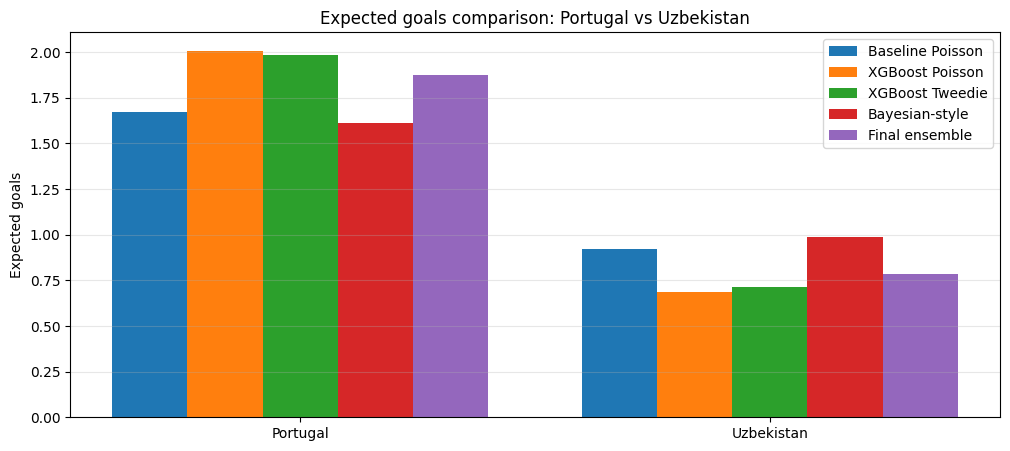

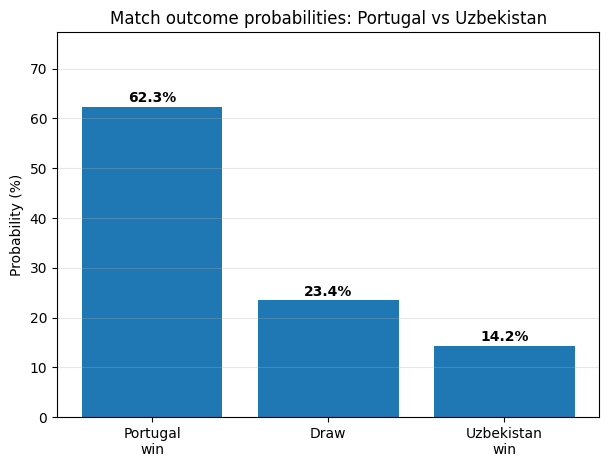

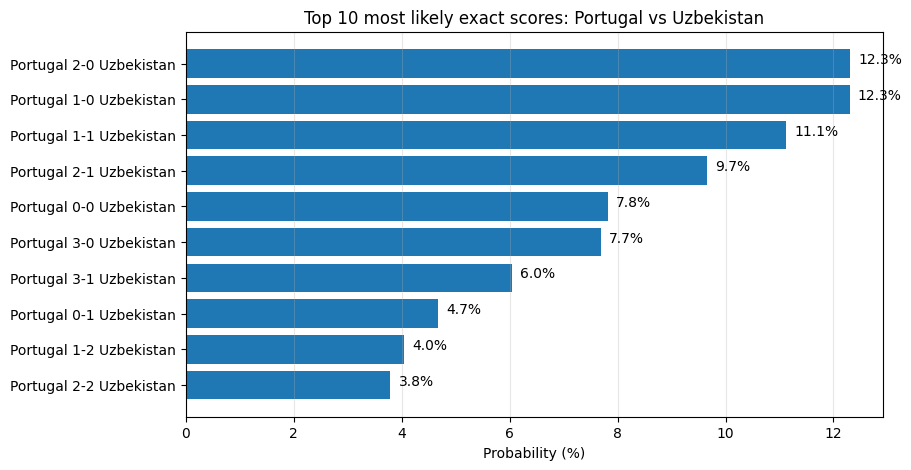

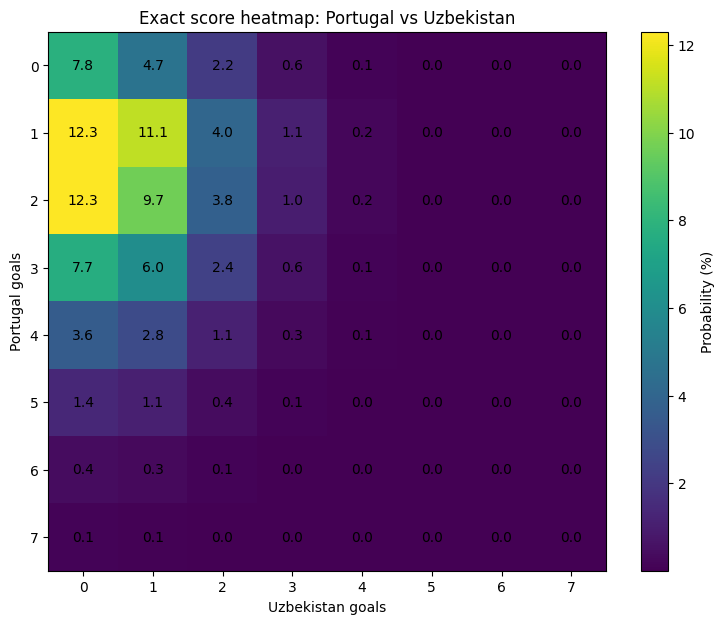

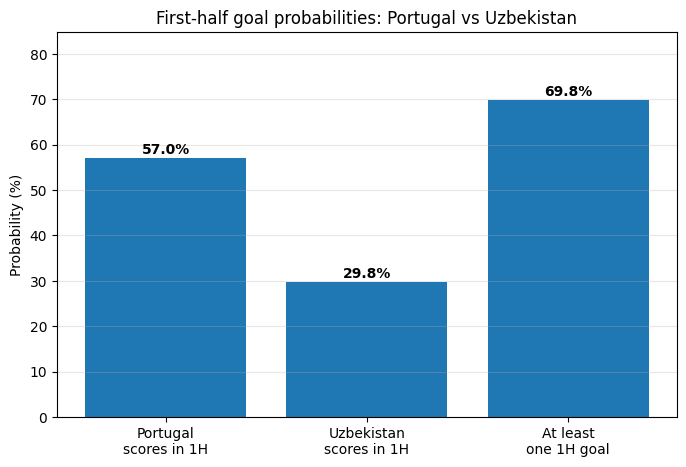

In [ ]:
single_result = predict_match_v4(
    "Portugal",
    "Uzbekistan",
    neutral=NEUTRAL_SITE,
    tournament=TOURNAMENT_NAME,
    match_date=MATCH_DATE,
    max_goals=MAX_GOALS,
    first_half_share=FIRST_HALF_GOAL_SHARE,
    show_plots=True
)

## 12. Full match slate summary

V4 HYBRID SCORE PREDICTION: Portugal vs Uzbekistan

Expected goals
Baseline Poisson — Portugal: 1.67, Uzbekistan: 0.92
XGBoost Poisson  — Portugal: 2.01, Uzbekistan: 0.69
XGBoost Tweedie  — Portugal: 1.98, Uzbekistan: 0.71
Bayesian-style   — Portugal: 1.61, Uzbekistan: 0.99
Final ensemble   — Portugal: 1.87, Uzbekistan: 0.78

Outcome probabilities
Portugal win: 62.3%
Draw: 23.4%
Uzbekistan win: 14.2%

Top exact scores


,score,home_goals,away_goals,probability
0,Portugal 2-0 Uzbekistan,2,0,12.305818
1,Portugal 1-0 Uzbekistan,1,0,12.302038
2,Portugal 1-1 Uzbekistan,1,1,11.127012
3,Portugal 2-1 Uzbekistan,2,1,9.658824
4,Portugal 0-0 Uzbekistan,0,0,7.824925
5,Portugal 3-0 Uzbekistan,3,0,7.691104
6,Portugal 3-1 Uzbekistan,3,1,6.036740
7,Portugal 0-1 Uzbekistan,0,1,4.670621
8,Portugal 1-2 Uzbekistan,1,2,4.043324
9,Portugal 2-2 Uzbekistan,2,2,3.790601



First-half probabilities
Portugal scores in 1H: 57.0%
Uzbekistan scores in 1H: 29.8%
At least one first-half goal: 69.8%


,team,baseline_poisson,xgb_poisson,xgb_tweedie,bayesian_style,final_ensemble
0,Portugal,1.671982,2.008097,1.982031,1.612327,1.874992
1,Uzbekistan,0.920766,0.685758,0.713174,0.987662,0.784899


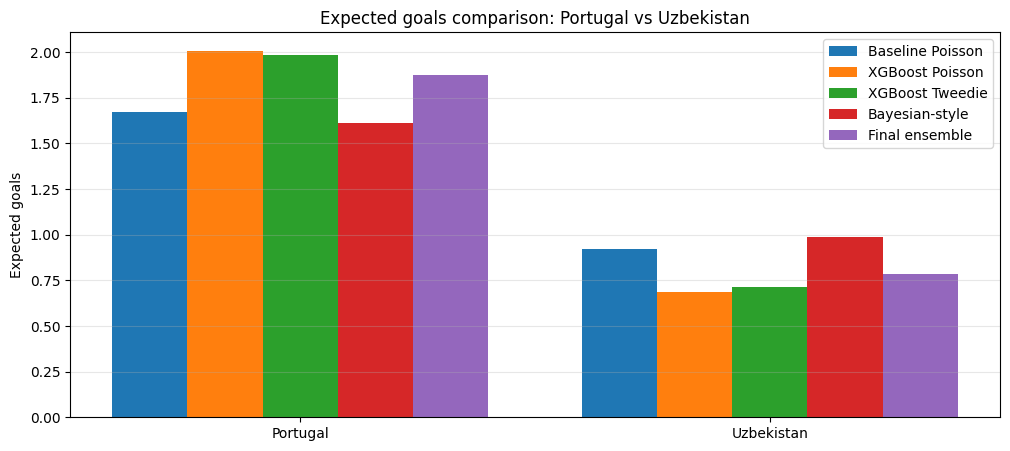

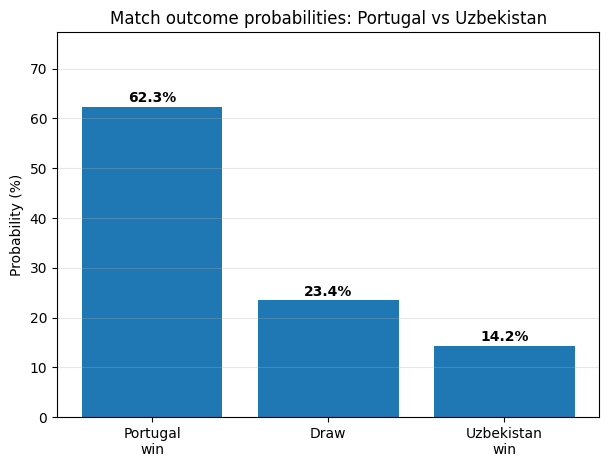

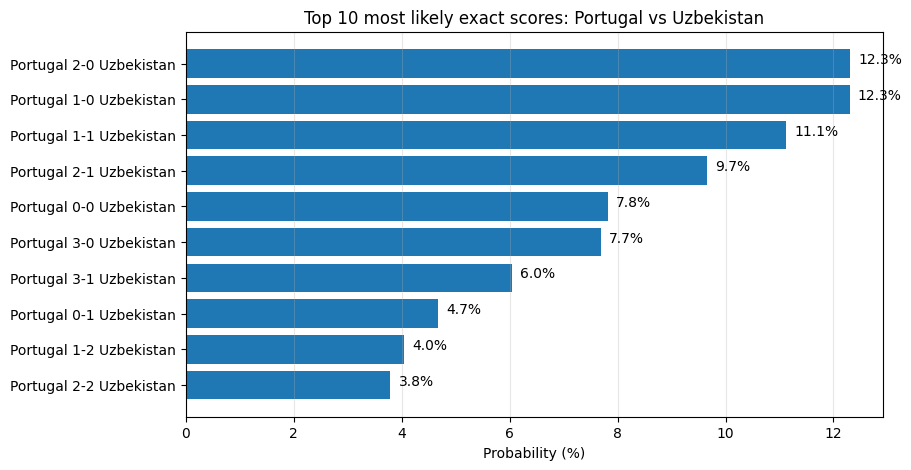

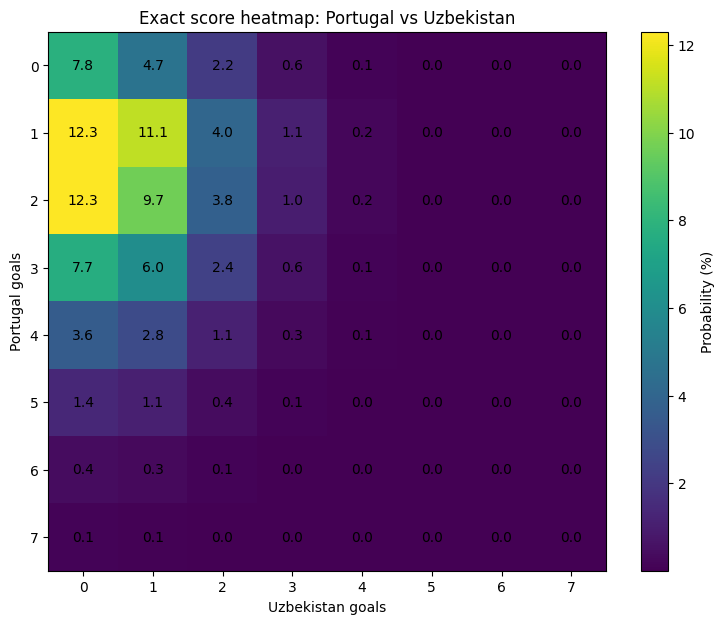

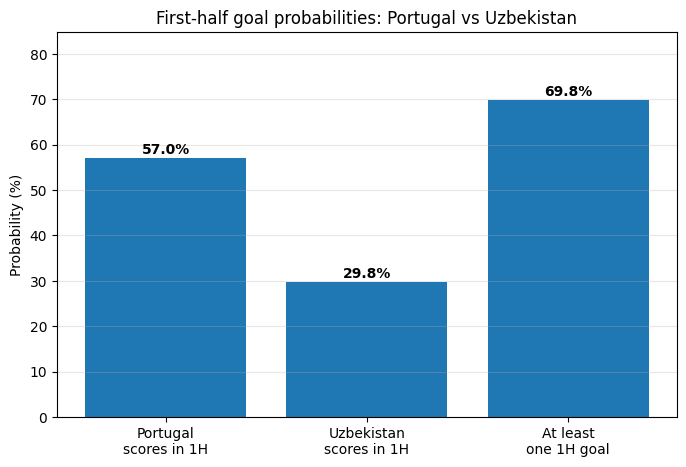

V4 HYBRID SCORE PREDICTION: England vs Ghana

Expected goals
Baseline Poisson — England: 1.85, Ghana: 0.53
XGBoost Poisson  — England: 2.21, Ghana: 0.52
XGBoost Tweedie  — England: 2.19, Ghana: 0.46
Bayesian-style   — England: 1.75, Ghana: 0.67
Final ensemble   — England: 2.06, Ghana: 0.53

Outcome probabilities
England win: 72.8%
Draw: 19.5%
Ghana win: 7.7%

Top exact scores


,score,home_goals,away_goals,probability
0,England 2-0 Ghana,2,0,15.932891
1,England 1-0 Ghana,1,0,14.795122
2,England 3-0 Ghana,3,0,10.953486
3,England 1-1 Ghana,1,1,8.849049
4,England 2-1 Ghana,2,1,8.449322
5,England 0-0 Ghana,0,0,8.146946
6,England 3-1 Ghana,3,1,5.808709
7,England 4-0 Ghana,4,0,5.647697
8,England 0-1 Ghana,0,1,3.317288
9,England 4-1 Ghana,4,1,2.995013



First-half probabilities
England scores in 1H: 60.5%
Ghana scores in 1H: 21.2%
At least one first-half goal: 68.9%


,team,baseline_poisson,xgb_poisson,xgb_tweedie,bayesian_style,final_ensemble
0,England,1.849161,2.206565,2.188871,1.751687,2.062429
1,Ghana,0.531112,0.523206,0.455248,0.673268,0.530307


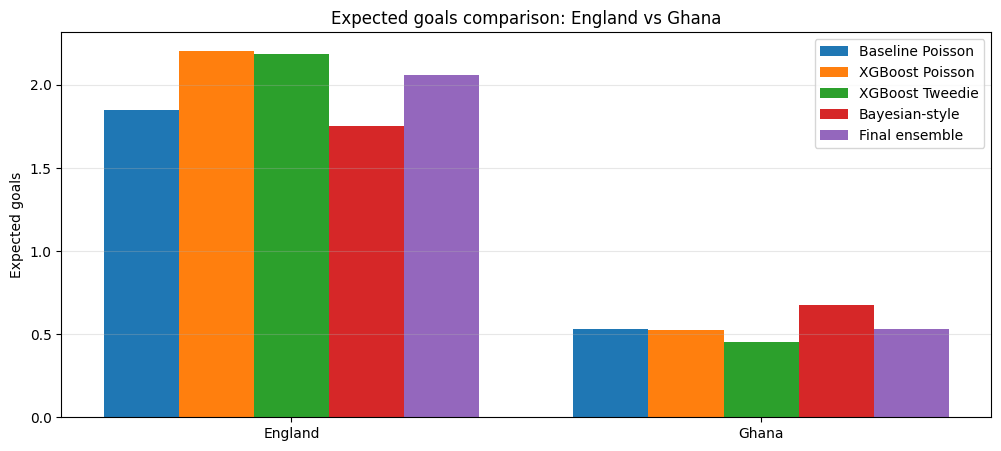

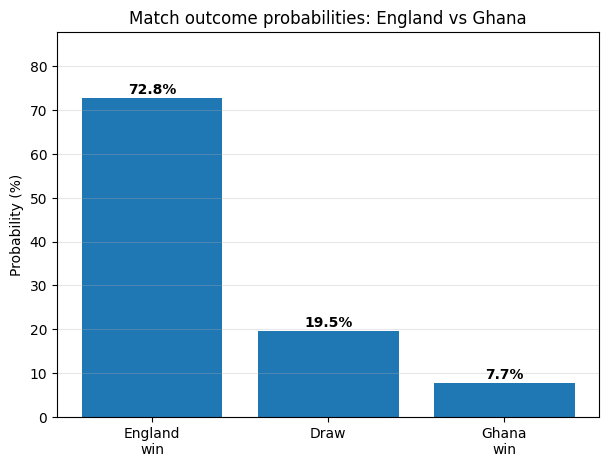

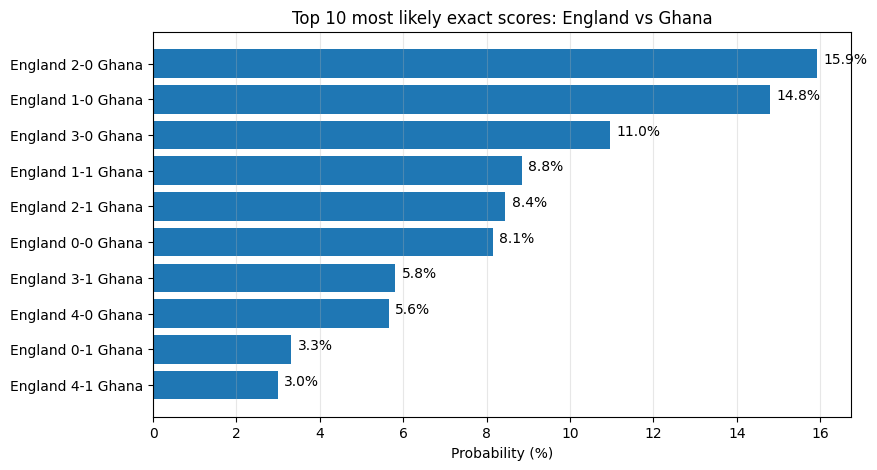

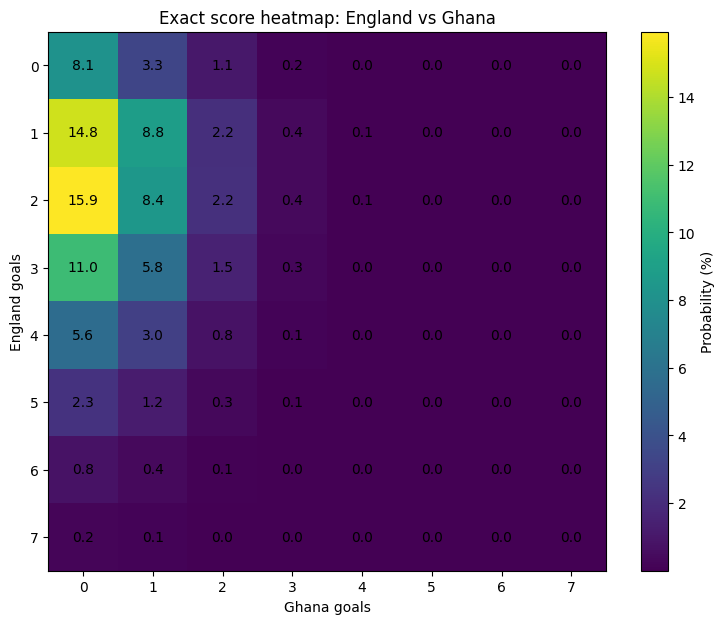

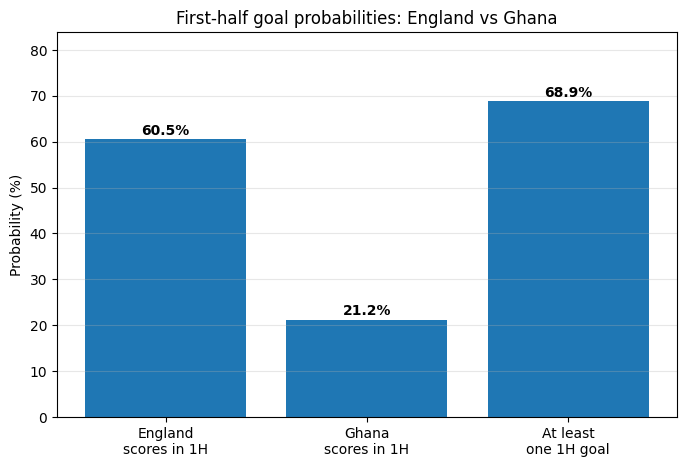

V4 HYBRID SCORE PREDICTION: Panama vs Croatia

Expected goals
Baseline Poisson — Panama: 1.33, Croatia: 1.60
XGBoost Poisson  — Panama: 0.94, Croatia: 1.69
XGBoost Tweedie  — Panama: 0.92, Croatia: 1.64
Bayesian-style   — Panama: 1.30, Croatia: 1.72
Final ensemble   — Panama: 1.07, Croatia: 1.66

Outcome probabilities
Panama win: 23.5%
Draw: 26.2%
Croatia win: 50.3%

Top exact scores


,score,home_goals,away_goals,probability
0,Panama 1-1 Croatia,1,1,12.505256
1,Panama 0-1 Croatia,0,1,9.908343
2,Panama 1-2 Croatia,1,2,9.623531
3,Panama 0-2 Croatia,0,2,9.004940
4,Panama 0-0 Croatia,0,0,7.444394
5,Panama 2-1 Croatia,2,1,6.187176
6,Panama 1-0 Croatia,1,0,6.039520
7,Panama 1-3 Croatia,1,3,5.332229
8,Panama 2-2 Croatia,2,2,5.142308
9,Panama 0-3 Croatia,0,3,4.989479



First-half probabilities
Panama scores in 1H: 38.2%
Croatia scores in 1H: 52.7%
At least one first-half goal: 70.7%


,team,baseline_poisson,xgb_poisson,xgb_tweedie,bayesian_style,final_ensemble
0,Panama,1.332021,0.940819,0.921167,1.304473,1.068695
1,Croatia,1.599280,1.687554,1.640334,1.715240,1.662247


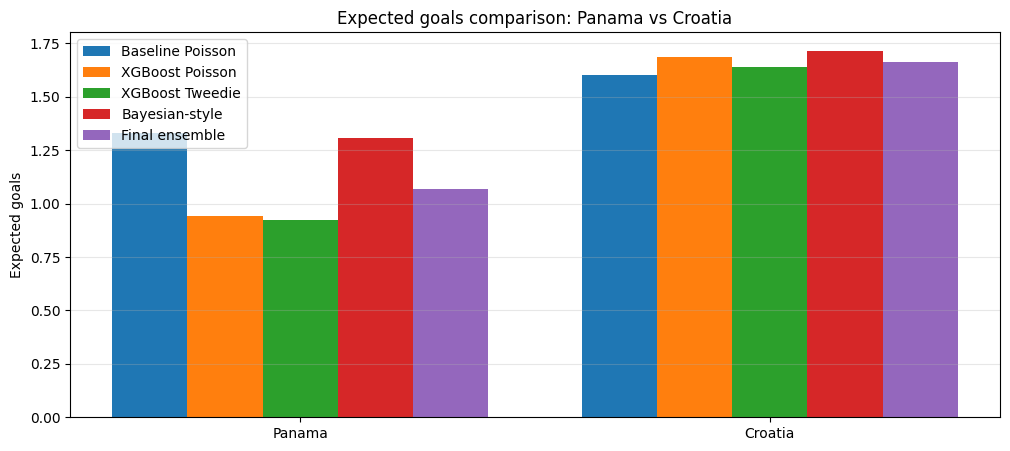

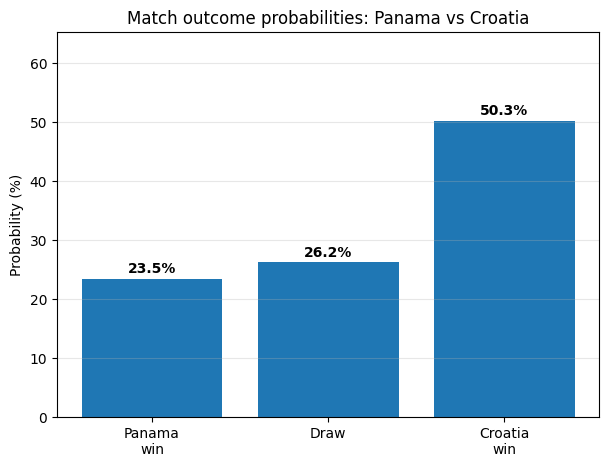

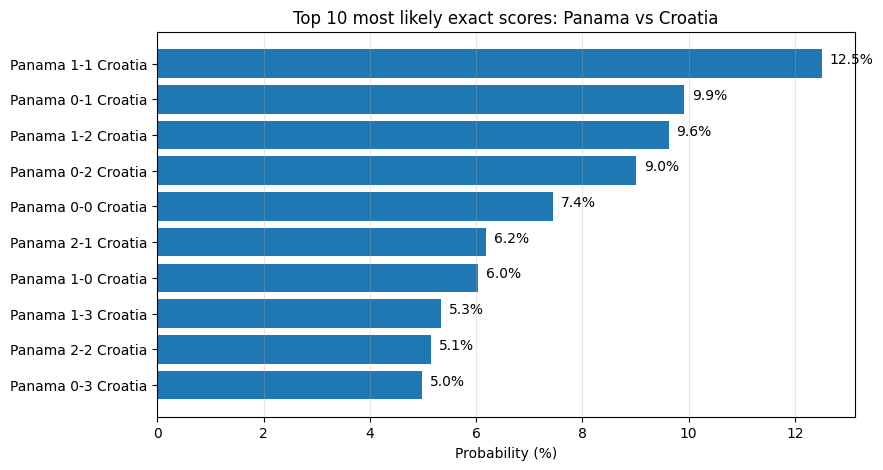

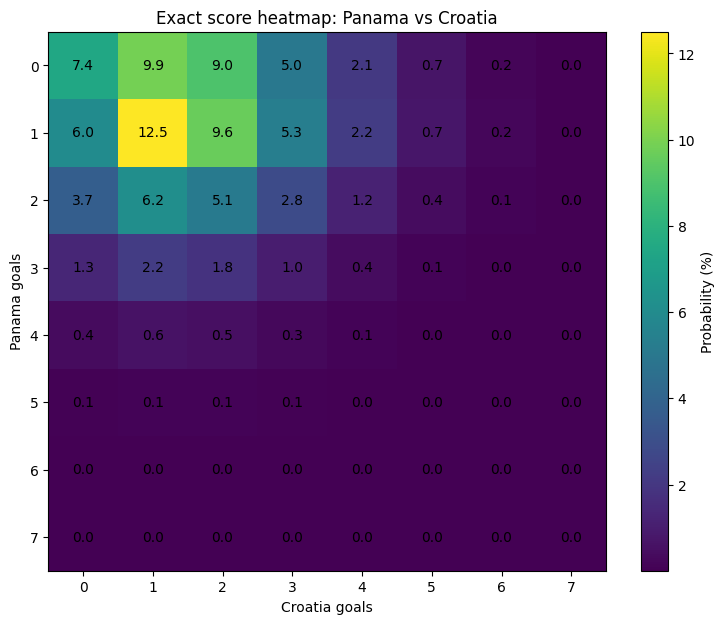

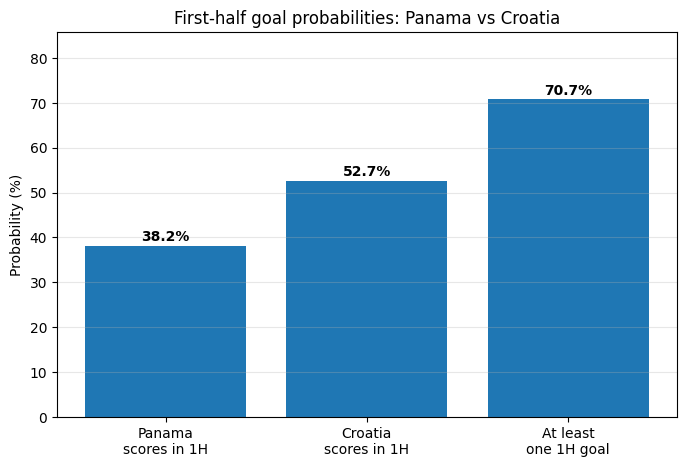

V4 HYBRID SCORE PREDICTION: Colombia vs DR Congo

Expected goals
Baseline Poisson — Colombia: 0.89, DR Congo: 0.73
XGBoost Poisson  — Colombia: 2.00, DR Congo: 0.64
XGBoost Tweedie  — Colombia: 2.02, DR Congo: 0.63
Bayesian-style   — Colombia: 1.04, DR Congo: 0.74
Final ensemble   — Colombia: 1.64, DR Congo: 0.67

Outcome probabilities
Colombia win: 59.9%
Draw: 26.0%
DR Congo win: 14.1%

Top exact scores


,score,home_goals,away_goals,probability
0,Colombia 1-0 DR Congo,1,0,15.411343
1,Colombia 2-0 DR Congo,2,0,13.350510
2,Colombia 1-1 DR Congo,1,1,11.785028
3,Colombia 0-0 DR Congo,0,0,10.804372
4,Colombia 2-1 DR Congo,2,1,8.946134
5,Colombia 3-0 DR Congo,3,0,7.296845
6,Colombia 0-1 DR Congo,0,1,5.782039
7,Colombia 3-1 DR Congo,3,1,4.889593
8,Colombia 1-2 DR Congo,1,2,3.656070
9,Colombia 2-2 DR Congo,2,2,2.997388



First-half probabilities
Colombia scores in 1H: 52.2%
DR Congo scores in 1H: 26.0%
At least one first-half goal: 64.6%


,team,baseline_poisson,xgb_poisson,xgb_tweedie,bayesian_style,final_ensemble
0,Colombia,0.886162,2.002515,2.020516,1.042070,1.639678
1,DR Congo,0.726214,0.643410,0.628022,0.736564,0.670097


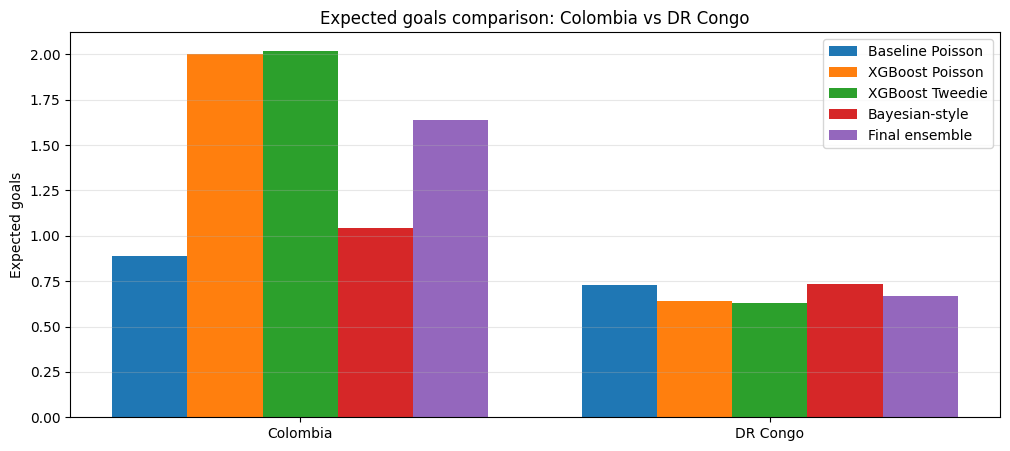

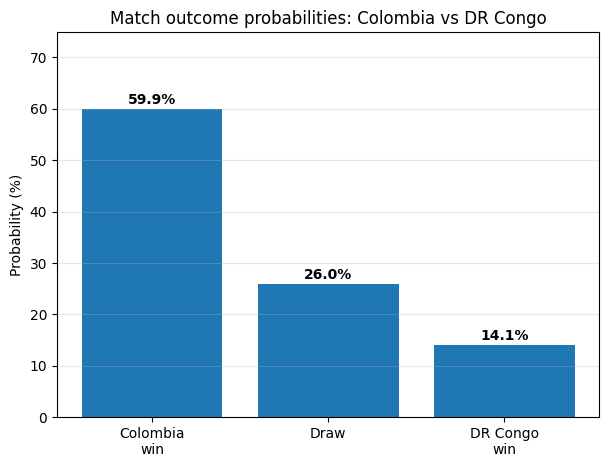

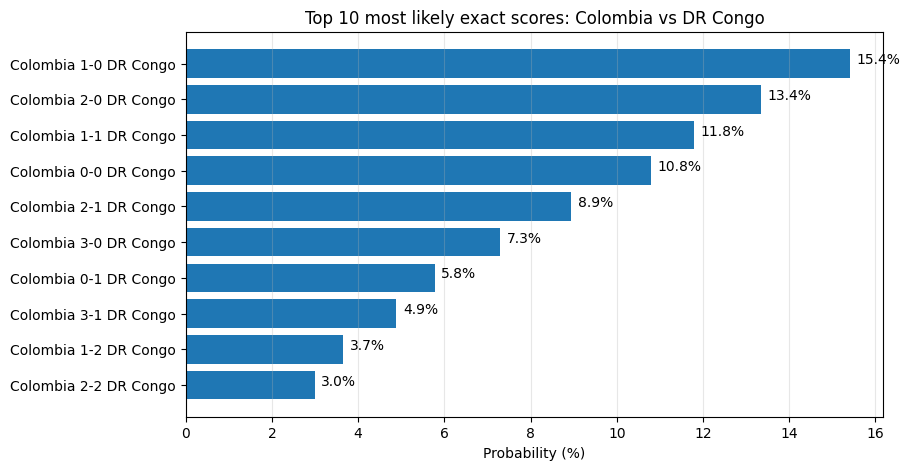

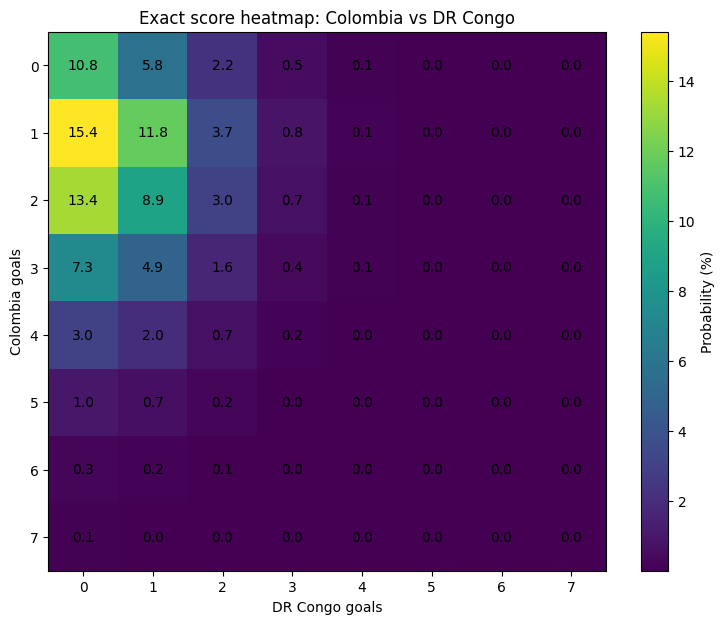

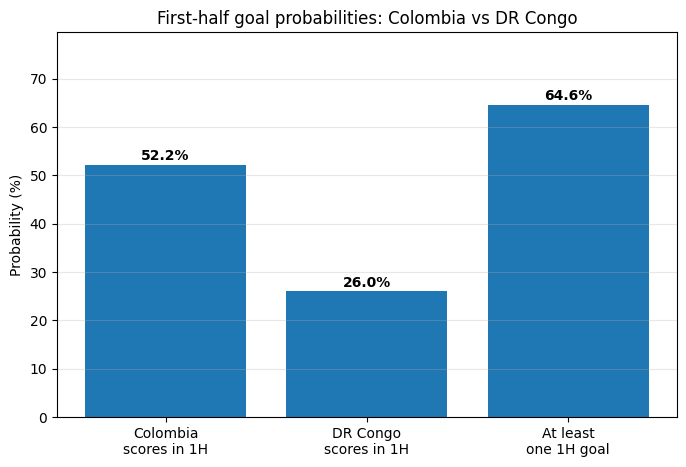

,match,home_xg,away_xg,home_win_%,draw_%,away_win_%,home_scores_1h_%,away_scores_1h_%,any_goal_1h_%,most_likely_score,most_likely_score_%
0,Portugal vs Uzbekistan,1.874992,0.784899,62.333532,23.422887,14.243582,56.990384,29.756651,69.788605,Portugal 2-0 Uzbekistan,12.305818
1,England vs Ghana,2.062429,0.530307,72.776907,19.528071,7.695022,60.469320,21.230011,68.861688,England 2-0 Ghana,15.932891
2,Panama vs Croatia,1.068695,1.662247,23.484133,26.228063,50.287804,38.178103,52.669310,70.739270,Panama 1-1 Croatia,12.505256
3,Colombia vs DR Congo,1.639678,0.670097,59.912112,25.978985,14.108903,52.186160,26.032441,64.633270,Colombia 1-0 DR Congo,15.411343


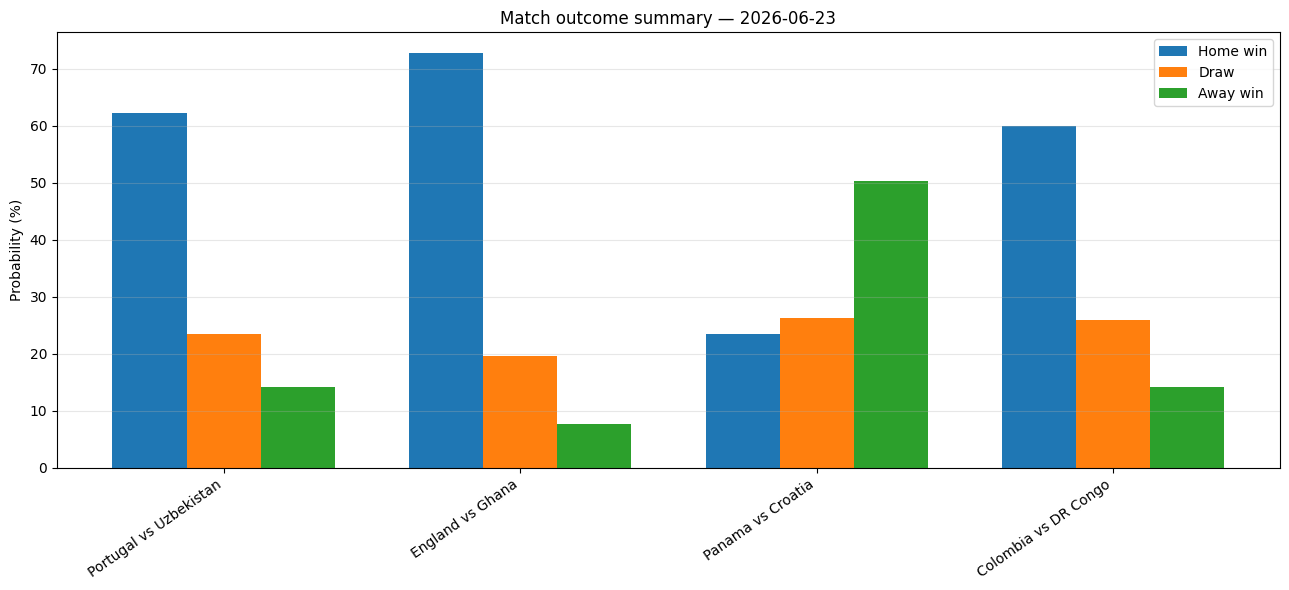

In [ ]:
summary_rows = []

for home_team, away_team in MATCHES_TO_PREDICT:
    try:
        result = predict_match_v4(
            home_team, away_team,
            neutral=NEUTRAL_SITE, tournament=TOURNAMENT_NAME,
            match_date=MATCH_DATE, max_goals=MAX_GOALS,
            first_half_share=FIRST_HALF_GOAL_SHARE, show_plots=True
        )
        summary_rows.append({
            "match": f"{result['home_team']} vs {result['away_team']}",
            "home_xg": result["final_home_expected_goals"],
            "away_xg": result["final_away_expected_goals"],
            "home_win_%": result["home_win_probability"] * 100,
            "draw_%": result["draw_probability"] * 100,
            "away_win_%": result["away_win_probability"] * 100,
            "home_scores_1h_%": result["home_scores_1h_probability"] * 100,
            "away_scores_1h_%": result["away_scores_1h_probability"] * 100,
            "any_goal_1h_%": result["any_goal_1h_probability"] * 100,
            "most_likely_score": result["top_scores"].iloc[0]["score"],
            "most_likely_score_%": result["top_scores"].iloc[0]["probability"],
        })
    except Exception as e:
        print(f"Error predicting {home_team} vs {away_team}: {e}")

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

if len(summary_df) > 0:
    x = np.arange(len(summary_df))
    width = 0.25
    plt.figure(figsize=(13, 6))
    plt.bar(x - width, summary_df["home_win_%"], width, label="Home win")
    plt.bar(x, summary_df["draw_%"], width, label="Draw")
    plt.bar(x + width, summary_df["away_win_%"], width, label="Away win")
    plt.xticks(x, summary_df["match"], rotation=35, ha="right")
    plt.ylabel("Probability (%)")
    plt.title(f"Match outcome summary — {MATCH_DATE}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

V4 HYBRID SCORE PREDICTION: Mexico vs Czech Republic

Expected goals
Baseline Poisson — Mexico: 1.30, Czech Republic: 1.07
XGBoost Poisson  — Mexico: 1.78, Czech Republic: 0.81
XGBoost Tweedie  — Mexico: 1.69, Czech Republic: 0.83
Bayesian-style   — Mexico: 1.46, Czech Republic: 1.16
Final ensemble   — Mexico: 1.61, Czech Republic: 0.92

Outcome probabilities
Mexico win: 52.6%
Draw: 26.8%
Czech Republic win: 20.6%

Top exact scores


,score,home_goals,away_goals,probability
0,Mexico 1-1 Czech Republic,1,1,12.741788
1,Mexico 1-0 Czech Republic,1,0,11.880126
2,Mexico 2-0 Czech Republic,2,0,10.329621
3,Mexico 2-1 Czech Republic,2,1,9.503176
4,Mexico 0-0 Czech Republic,0,0,8.904148
5,Mexico 0-1 Czech Republic,0,1,6.379593
6,Mexico 3-0 Czech Republic,3,0,5.546963
7,Mexico 1-2 Czech Republic,1,2,5.427015
8,Mexico 3-1 Czech Republic,3,1,5.103166
9,Mexico 2-2 Czech Republic,2,2,4.371427



First-half probabilities
Mexico scores in 1H: 51.6%
Czech Republic scores in 1H: 33.9%
At least one first-half goal: 68.0%


,team,baseline_poisson,xgb_poisson,xgb_tweedie,bayesian_style,final_ensemble
0,Mexico,1.295757,1.777427,1.685228,1.463723,1.610987
1,Czech Republic,1.068181,0.812060,0.830417,1.159523,0.919993


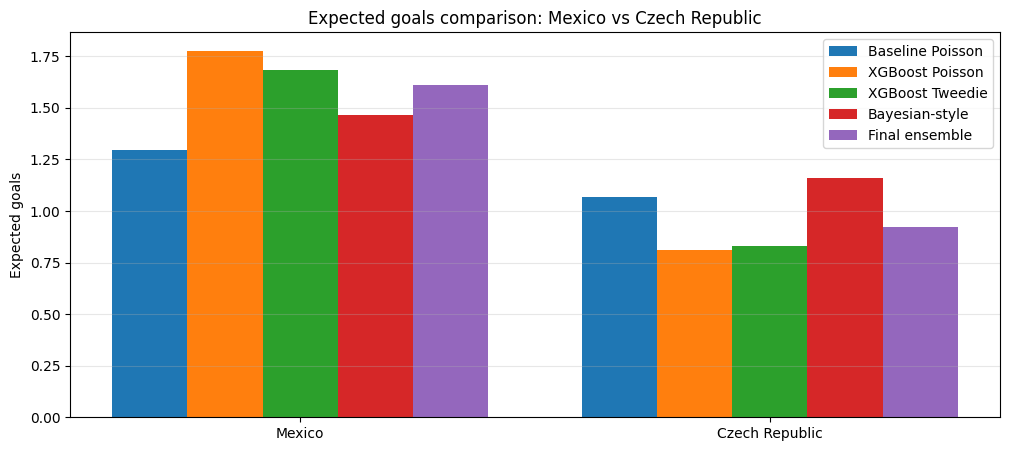

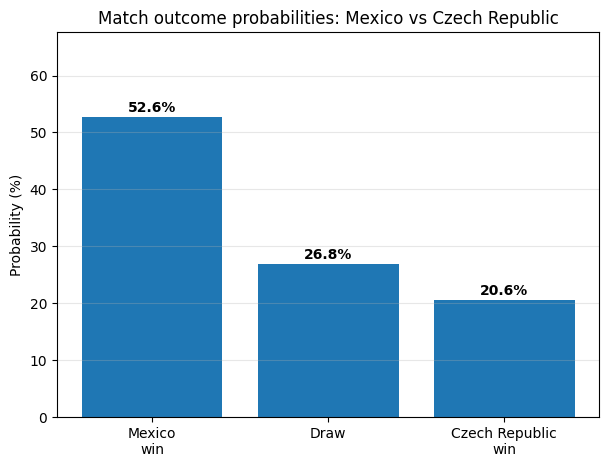

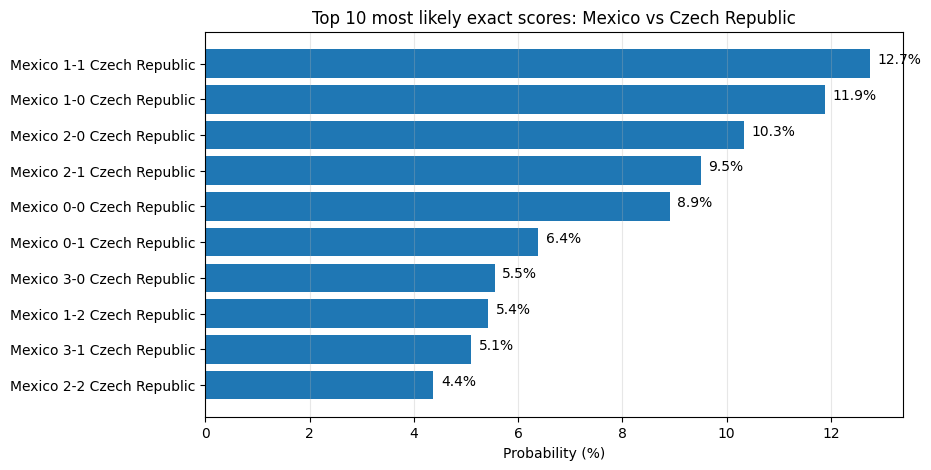

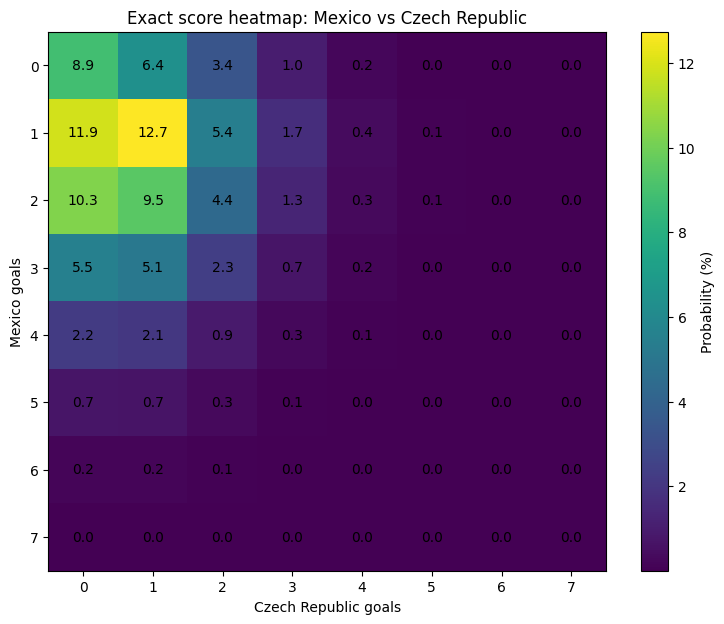

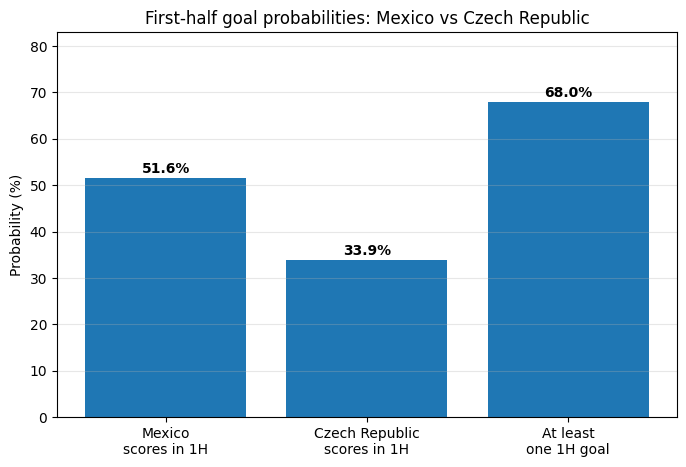

In [ ]:
single_result = predict_match_v4(
    "Mexico",
    "Czech Republic",
    neutral=NEUTRAL_SITE,
    tournament=TOURNAMENT_NAME,
    match_date=MATCH_DATE,
    max_goals=MAX_GOALS,
    first_half_share=FIRST_HALF_GOAL_SHARE,
    show_plots=True
)

V4 HYBRID SCORE PREDICTION: Germany vs Ecuador

Expected goals
Baseline Poisson — Germany: 1.34, Ecuador: 1.03
XGBoost Poisson  — Germany: 1.66, Ecuador: 0.94
XGBoost Tweedie  — Germany: 1.64, Ecuador: 0.97
Bayesian-style   — Germany: 1.54, Ecuador: 1.08
Final ensemble   — Germany: 1.57, Ecuador: 0.99

Outcome probabilities
Germany win: 50.0%
Draw: 27.2%
Ecuador win: 22.8%

Top exact scores


,score,home_goals,away_goals,probability
0,Germany 1-1 Ecuador,1,1,12.969288
1,Germany 1-0 Ecuador,1,0,11.217244
2,Germany 2-0 Ecuador,2,0,9.572513
3,Germany 2-1 Ecuador,2,1,9.439409
4,Germany 0-0 Ecuador,0,0,8.706931
5,Germany 0-1 Ecuador,0,1,6.677845
6,Germany 1-2 Ecuador,1,2,5.920812
7,Germany 3-0 Ecuador,3,0,5.016342
8,Germany 3-1 Ecuador,3,1,4.946591
9,Germany 2-2 Ecuador,2,2,4.654078



First-half probabilities
Germany scores in 1H: 50.7%
Ecuador scores in 1H: 35.8%
At least one first-half goal: 68.4%


,team,baseline_poisson,xgb_poisson,xgb_tweedie,bayesian_style,final_ensemble
0,Germany,1.342809,1.655213,1.643364,1.537467,1.572108
1,Ecuador,1.028492,0.939232,0.970799,1.080029,0.986095


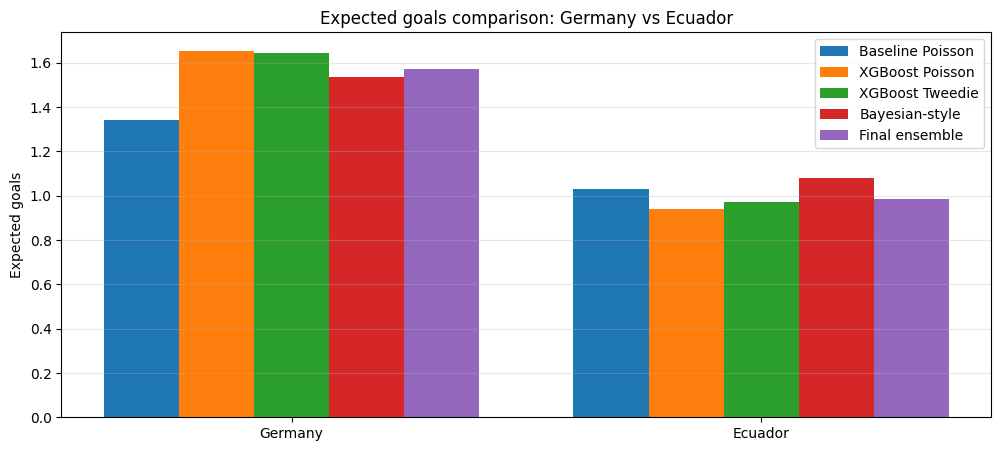

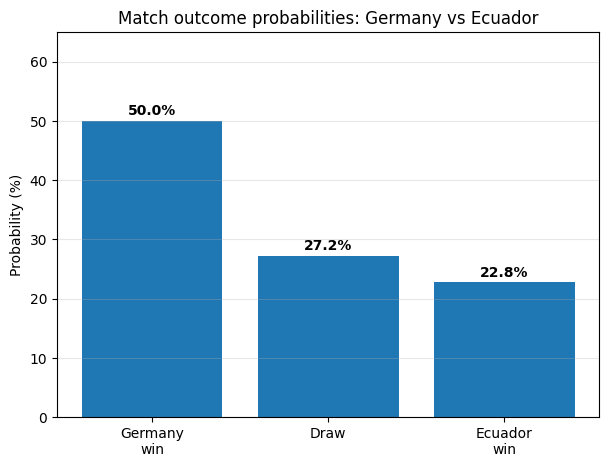

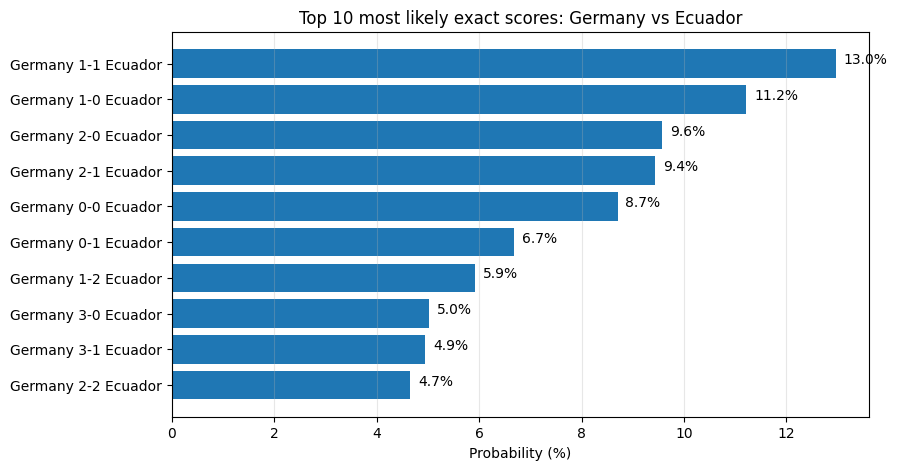

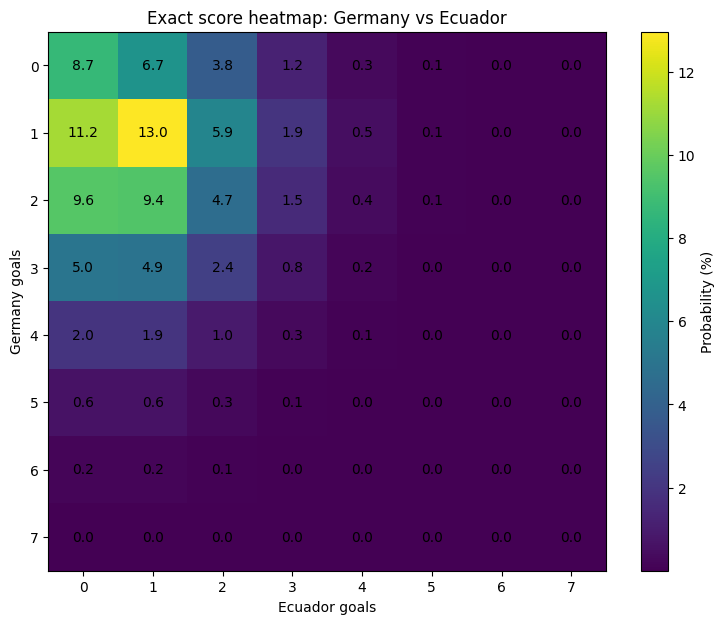

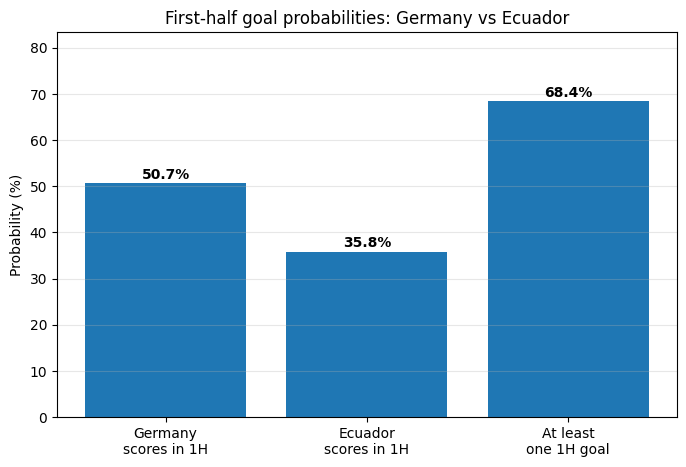

In [ ]:
single_result = predict_match_v4(
    "Germany",
    "Ecuador",
    neutral=NEUTRAL_SITE,
    tournament=TOURNAMENT_NAME,
    match_date=MATCH_DATE,
    max_goals=MAX_GOALS,
    first_half_share=FIRST_HALF_GOAL_SHARE,
    show_plots=True
)

## 13. GitHub / LinkedIn talking points

This notebook introduces Tweedie regression as an experimental model for overdispersed football goal counts.

Key points:

- Poisson is interpretable but conservative.
- Tweedie is more flexible for variance modeling.
- Real volatility features are better than artificial random noise.
- The final prediction uses an ensemble to reduce dependency on a single model assumption.

Recommended next steps:

1. Add FIFA ranking differences.
2. Add external Elo ratings.
3. Add rest days, travel distance, altitude and weather.
4. Add player injuries and expected lineups.
5. Replace empirical shrinkage with full PyMC MCMC.
6. Track predictions and calculate Brier Score, Log Loss and calibration curves.